In [1]:
!pip install pandas matplotlib  seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect, event
from datetime import datetime
import numpy as np


In [2]:
# 1. Create the connection (Using the Trusted Connection we discussed)
# Replace 'YOUR_SERVER' with your actual server name from SSMS
server = 'FrancisATK'
database = 'Grocery Shopping'
connection_url = f"mssql+pyodbc://{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&Trusted_Connection=yes"

engine = create_engine(connection_url)


@event.listens_for(engine, "before_cursor_execute")
def receive_before_cursor_execute(conn, cursor, statement, parameters, context, executemany):
    if executemany:
        cursor.fast_executemany = True



# Create the inspector object
inspector = inspect(engine)

# Get all table names
table_names = inspector.get_table_names()

print("Available tables in your database:")
print(table_names)

Available tables in your database:
['CustomerSpending', 'dim_categories', 'dim_cities', 'dim_countries', 'dim_customers', 'dim_employees', 'dim_products', 'fact_sales']


## Data Cleaning and Transformation

### dim_categories


In [3]:
# Access the table using a SQL Query

url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/main/GrocerySalesAnalysis/RawData/categories.csv"
df_categories = pd.read_csv(url)

df_categories.head()


,CategoryID,CategoryName,Department
0,1,Confections,Pantry & Snacks
1,2,Cereals & Grains,Pantry & Snacks
2,3,Pantry & Spices,Pantry & Snacks
3,4,Dairy,Fresh & Perishables
4,5,Fruits & Vegetables,Fresh & Perishables


In [4]:
# Perform cleaning (e.g., removing leading spaces, standardizing case)
df_categories['CategoryName'] = df_categories['CategoryName'].str.strip().str.title()

# Check duplicate
print(df_categories.duplicated().sum())

# Check null values
print(df_categories.isnull().sum())

0
CategoryID      0
CategoryName    0
Department      0
dtype: int64


In [5]:
# Data type validation
df_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CategoryID    13 non-null     int64 
 1   CategoryName  13 non-null     object
 2   Department    13 non-null     object
dtypes: int64(1), object(2)
memory usage: 440.0+ bytes


In [6]:
df_categories.head(13)

,CategoryID,CategoryName,Department
0,1,Confections,Pantry & Snacks
1,2,Cereals & Grains,Pantry & Snacks
2,3,Pantry & Spices,Pantry & Snacks
3,4,Dairy,Fresh & Perishables
4,5,Fruits & Vegetables,Fresh & Perishables
5,6,Seafood,Fresh & Perishables
6,7,Meat,Fresh & Perishables
7,8,Beverages,Beverages & Alcohol
8,9,Poultry,Fresh & Perishables
9,10,Household & Misc,Household & Misc


In [7]:
df_categories.head(13)

,CategoryID,CategoryName,Department
0,1,Confections,Pantry & Snacks
1,2,Cereals & Grains,Pantry & Snacks
2,3,Pantry & Spices,Pantry & Snacks
3,4,Dairy,Fresh & Perishables
4,5,Fruits & Vegetables,Fresh & Perishables
5,6,Seafood,Fresh & Perishables
6,7,Meat,Fresh & Perishables
7,8,Beverages,Beverages & Alcohol
8,9,Poultry,Fresh & Perishables
9,10,Household & Misc,Household & Misc


In [8]:
# Save the enriched DataFrame back to SQL Server
df_categories.to_sql('dim_categories', engine, if_exists='replace', index=False)

13

### dim_product


In [9]:
# Access the table using a SQL Query

url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/refs/heads/main/GrocerySalesAnalysis/RawData/products.csv"
df_products = pd.read_csv(url)


df_products.head()

,ProductID,ProductName,Price,CategoryID,Class,ModifyDate,Resistant,IsAllergic,VitalityDays
0,1,Flour - Whole Wheat,74.2988,2,Medium,21:49.2,Durable,Unknown,0
1,2,Cookie Chocolate Chip With,91.2329,1,Medium,39:11.0,Unknown,Unknown,0
2,3,Onions - Cippolini,9.1379,5,Medium,11:51.6,Weak,FALSE,111
3,4,"Sauce - Gravy, Au Jus, Mix",54.3055,3,Medium,46:28.9,Durable,Unknown,0
4,5,Artichokes - Jerusalem,65.4771,5,Low,13:35.4,Durable,TRUE,27


In [10]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     452 non-null    int64  
 1   ProductName   452 non-null    object 
 2   Price         452 non-null    float64
 3   CategoryID    452 non-null    int64  
 4   Class         452 non-null    object 
 5   ModifyDate    452 non-null    object 
 6   Resistant     452 non-null    object 
 7   IsAllergic    452 non-null    object 
 8   VitalityDays  452 non-null    int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 31.9+ KB


#### Duplicate check

In [11]:
df_products.duplicated().sum()

np.int64(0)

In [12]:
df_products['Price'] = df_products['Price'].round(2)

#### IsAllergic: None to False

In [13]:
# Convert 'IsAllergic' to string first
df_products['IsAllergic'] = df_products['IsAllergic'].astype(str).str.strip().str.title()

# Assume that 'None' and 'Nan' should be treated as False
# Convert to proper Boolean values
df_products['IsAllergic'] = df_products['IsAllergic'].map({'True': True, 'False': False,'None' : False, 'Nan' : False})

# change the data type of 'IsAllergic' to boolean
df_products['IsAllergic'] = df_products['IsAllergic'].astype(bool)

print(df_products['IsAllergic'].value_counts())

IsAllergic
True     287
False    165
Name: count, dtype: int64


#### Price, Vitalidays: No negative values

In [14]:
# Quick statistics check Price and VitalityDays
print(df_products[[ 'Price', 'VitalityDays']].describe())

            Price  VitalityDays
count  452.000000    452.000000
mean    50.801836     26.030973
std     28.616962     39.061200
min      0.040000      0.000000
25%     26.505000      0.000000
50%     52.500000      0.000000
75%     75.497500     52.500000
max     99.880000    120.000000


#### Adding UnitCost to the products table

In [15]:
# Categoryid map
category_map = df_categories.set_index('CategoryID')['CategoryName']
df_products['CategoryName'] = df_products['CategoryID'].map(category_map)

# create a 'UnitCost' column
# Industrial practice: Variable margins by Category
category_margins = {
    'Confections': 0.35,
    'Cereals & Grains': 0.28,
    'Pantry & Spices': 0.35,
    'Dairy': 0.18,
    'Fruits & Vegetables': 0.12, # Replaces 'Fresh & Chilled'
    'Seafood': 0.18,
    'Meat': 0.14,
    'Beverages': 0.40,
    'Poultry': 0.13,
    'Household & Misc': 0.45,
    'Spirit': 0.32,
    'Beer': 0.22,
    'Wine': 0.38,
    'Specialty & Misc': 0.25
}

# map the department margin to the products
df_products['Margin'] = df_products['CategoryName'].map(category_margins)

# Calculate the unit cost based on the price and category margin
df_products['UnitCost'] = df_products['Price'] / (1 + df_products['Margin'])

# Calcualte the profit per unit
df_products['ProfitPerUnit'] = df_products['Price'] - df_products['UnitCost']


In [16]:
df_products['Resistant'].value_counts()

Resistant
Durable    164
Weak       148
Unknown    140
Name: count, dtype: int64

In [17]:
df_products.sample(10)

,ProductID,ProductName,Price,CategoryID,Class,ModifyDate,Resistant,IsAllergic,VitalityDays,CategoryName,Margin,UnitCost,ProfitPerUnit
81,82,Jolt Cola - Electric Blue,56.81,10,Low,56:24.0,Unknown,True,63,Household & Misc,0.45,39.179310,17.630690
133,134,Wine - Toasted Head,39.85,13,High,09:17.2,Weak,True,0,Wine,0.38,28.876812,10.973188
317,318,Ecolab - Solid Fusion,57.26,10,High,46:26.0,Unknown,True,76,Household & Misc,0.45,39.489655,17.770345
77,78,Wine - Magnotta - Belpaese,30.42,13,Medium,49:41.4,Weak,True,0,Wine,0.38,22.043478,8.376522
286,287,Bread - Italian Roll With Herbs,57.71,5,Medium,41:07.5,Durable,True,0,Fruits & Vegetables,0.12,51.526786,6.183214
313,314,Salmon Steak - Cohoe 8 Oz,5.60,6,Medium,09:48.3,Unknown,True,82,Seafood,0.18,4.745763,0.854237
362,363,Cornflakes,48.77,5,High,29:29.1,Unknown,True,0,Fruits & Vegetables,0.12,43.544643,5.225357
91,92,"Wine - Red, Colio Cabernet",60.22,13,Low,25:50.0,Weak,True,0,Wine,0.38,43.637681,16.582319
249,250,"Soup - Campbells, Beef Barley",64.50,7,Low,55:14.0,Durable,False,0,Meat,0.14,56.578947,7.921053
442,443,Lettuce - Spring Mix,90.02,5,Low,10:08.0,Unknown,False,79,Fruits & Vegetables,0.12,80.375000,9.645000


In [18]:
# Save the enriched DataFrame back to SQL Server
df_products.to_sql('dim_products',  engine, if_exists='replace', index=False)

130

In [19]:
df_products['CategoryID'].value_counts()

CategoryID
10    99
5     95
7     41
4     35
13    33
1     30
6     28
3     25
2     22
8     17
9     10
11    10
12     7
Name: count, dtype: int64

### dim_cities

In [20]:
# Access the table using a SQL Query
url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/refs/heads/main/GrocerySalesAnalysis/RawData/cities.csv"
df_cities = pd.read_csv(url)
df_cities.head()

,CityID,CityName,Zipcode,CountryID
0,1,Dayton,80563,32
1,2,Buffalo,17420,32
2,3,Chicago,44751,32
3,4,Fremont,20641,32
4,5,Virginia Beach,62389,32


In [21]:
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CityID     96 non-null     int64 
 1   CityName   96 non-null     object
 2   Zipcode    96 non-null     int64 
 3   CountryID  96 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 3.1+ KB


In [22]:
# Perform cleaning (e.g., removing leading spaces, standardizing case)
df_cities['CityName'] = df_cities['CityName'].str.strip().str.title()

In [23]:
df_cities.head()

,CityID,CityName,Zipcode,CountryID
0,1,Dayton,80563,32
1,2,Buffalo,17420,32
2,3,Chicago,44751,32
3,4,Fremont,20641,32
4,5,Virginia Beach,62389,32


#### Add state feature

In [24]:
# Define the long-form mapping dictionary
long_form_state_map = {
    'Dayton': 'Ohio', 'Buffalo': 'New York', 'Chicago': 'Illinois', 'Fremont': 'California',
    'Virginia Beach': 'Virginia', 'Austin': 'Texas', 'Riverside': 'California', 'Arlington': 'Texas',
    'Atlanta': 'Georgia', 'Toledo': 'Ohio', 'Spokane': 'Washington', 'Tacoma': 'Washington',
    'Akron': 'Ohio', 'Indianapolis': 'Indiana', 'Colorado': 'Colorado', 'Norfolk': 'Virginia',
    'St. Louis': 'Missouri', 'Little Rock': 'Arkansas', 'Omaha': 'Nebraska', 'El Paso': 'Texas',
    'Milwaukee': 'Wisconsin', 'Baton Rouge': 'Louisiana', 'Anaheim': 'California', 'Lincoln': 'Nebraska',
    'Boston': 'Massachusetts', 'Des Moines': 'Iowa', 'Mesa': 'Arizona', 'Tucson': 'Arizona',
    'Washington': 'District of Columbia', 'Philadelphia': 'Pennsylvania', 'Wichita': 'Kansas', 'Jackson': 'Mississippi',
    'Minneapolis': 'Minnesota', 'Fort Wayne': 'Indiana', 'Greensboro': 'North Carolina', 'Detroit': 'Michigan',
    'Fresno': 'California', 'Richmond': 'Virginia', 'Lubbock': 'Texas', 'Cleveland': 'Ohio',
    'Bakersfield': 'California', 'Denver': 'Colorado', 'Glendale': 'Arizona', 'Memphis': 'Tennessee',
    'Dallas': 'Texas', 'New York': 'New York', 'San Francisco': 'California', 'Long Beach': 'California',
    'Montgomery': 'Alabama', 'Cincinnati': 'Ohio', 'Portland': 'Oregon', 'Madison': 'Wisconsin',
    'Las Vegas': 'Nevada', 'Albuquerque': 'New Mexico', 'Houston': 'Texas', 'Stockton': 'California',
    'Nashville': 'Tennessee', 'Columbus': 'Ohio', 'Kansas': 'Missouri', 'Fort Worth': 'Texas',
    'Miami': 'Florida', 'Mobile': 'Alabama', 'Tulsa': 'Oklahoma', 'Raleigh': 'North Carolina',
    'Baltimore': 'Maryland', 'Shreveport': 'Louisiana', 'Corpus Christi': 'Texas', 'Anchorage': 'Alaska',
    'Oakland': 'California', 'Rochester': 'New York', 'Phoenix': 'Arizona', 'Honolulu': 'Hawaii',
    'Santa Ana': 'California', 'Tampa': 'Florida', 'San Antonio': 'Texas', 'Birmingham': 'Alabama',
    'Louisville': 'Kentucky', 'San Diego': 'California', 'Oklahoma': 'Oklahoma', 'New Orleans': 'Louisiana',
    'Sacramento': 'California', 'Charlotte': 'North Carolina', 'Aurora': 'Colorado', 'Newark': 'New Jersey',
    'St. Petersburg': 'Florida', 'San Jose': 'California', 'Los Angeles': 'California', 'Seattle': 'Washington',
    'St. Paul': 'Minnesota', 'Grand Rapids': 'Michigan', 'Jacksonville': 'Florida', 'Hialeah': 'Florida',
    'Jersey': 'New Jersey', 'Yonkers': 'New York', 'Garland': 'Texas', 'Pittsburgh': 'Pennsylvania'
}

# Create a new column based on the mapping
df_cities['State'] = df_cities['CityName'].map(long_form_state_map)

In [25]:
df_cities.head()

,CityID,CityName,Zipcode,CountryID,State
0,1,Dayton,80563,32,Ohio
1,2,Buffalo,17420,32,New York
2,3,Chicago,44751,32,Illinois
3,4,Fremont,20641,32,California
4,5,Virginia Beach,62389,32,Virginia


In [26]:
df_cities.drop_duplicates(inplace=True)

#### Zipcode Standardization

In [27]:
# check for invalid lengths (anything not equal to 5)
df_cities['ZipcodeLength'] = df_cities['Zipcode'].astype(str).str.len()
invalid_lengths = df_cities[df_cities['ZipcodeLength'] != 5]

print(invalid_lengths[['CityName', 'Zipcode', 'ZipcodeLength']])

         CityName  Zipcode  ZipcodeLength
5          Austin      781              3
6       Riverside     1439              4
46  San Francisco      157              3
48     Montgomery     8944              4
60          Miami     6794              4
69      Rochester      415              3
74    San Antonio     3863              4
76     Louisville     4409              4
93        Yonkers     7430              4


In [28]:
# Add leading zeros to Zipcode if length is less than 5
df_cities['Zipcode'] = df_cities['Zipcode'].astype(str).str.zfill(5)


In [29]:
# check for invalid lengths (anything not equal to 5)
df_cities['ZipcodeLength'] = df_cities['Zipcode'].astype(str).str.len()
invalid_lengths = df_cities[df_cities['ZipcodeLength'] != 5]

print(invalid_lengths[['CityName', 'Zipcode', 'ZipcodeLength']])

Empty DataFrame
Columns: [CityName, Zipcode, ZipcodeLength]
Index: []


In [30]:
df_cities.drop(columns=['ZipcodeLength'], inplace=True)

In [31]:
df_cities.head(10)

,CityID,CityName,Zipcode,CountryID,State
0,1,Dayton,80563,32,Ohio
1,2,Buffalo,17420,32,New York
2,3,Chicago,44751,32,Illinois
3,4,Fremont,20641,32,California
4,5,Virginia Beach,62389,32,Virginia
5,6,Austin,00781,32,Texas
6,7,Riverside,01439,32,California
7,8,Arlington,12654,32,Texas
8,9,Atlanta,66212,32,Georgia
9,10,Toledo,52048,32,Ohio


In [32]:
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CityID     96 non-null     int64 
 1   CityName   96 non-null     object
 2   Zipcode    96 non-null     object
 3   CountryID  96 non-null     int64 
 4   State      96 non-null     object
dtypes: int64(2), object(3)
memory usage: 3.9+ KB


In [33]:
df_cities.drop_duplicates(inplace=True)

In [34]:
# Save the enriched DataFrame back to SQL Server
df_cities.to_sql('dim_cities',  engine, if_exists='replace', index=False)

96

### dim_countries

In [35]:
# Access the table using a SQL Query

url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/refs/heads/main/GrocerySalesAnalysis/RawData/countries.csv"
df_countries = pd.read_csv(url)
df_countries.head()

,CountryID,CountryName,CountryCode
0,1,Armenia,AN
1,2,Canada,FO
2,3,Belize,MK
3,4,Uganda,LV
4,5,Thailand,VI


In [36]:
df_countries.drop_duplicates(inplace=True)

#### CountryName cleaning

In [37]:
# Perform cleaning (e.g., removing leading spaces, standardizing case)
df_countries['CountryName'] = df_countries['CountryName'].str.strip().str.title()

In [38]:
# Save the enriched DataFrame back to SQL Server
df_countries.to_sql('dim_countries',  engine, if_exists='replace', index=False)

207

### dim_customers

In [39]:
# Access the table using a SQL Query
url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/refs/heads/main/GrocerySalesAnalysis/RawData/customers.csv"
df_customers = pd.read_csv(url)
df_customers.sample(20)

,CustomerID,FirstName,MiddleInitial,LastName,CityID,Address
88950,88951,Ericka,Q,Stone,95,40 South White Clarendon Drive
60926,60927,Todd,R,Browning,69,203 White New Way
3162,3163,Toni,L,Parker,38,12 Rocky Fabien Way
94920,94921,Audra,G,Mahoney,51,93 Clarendon Way
52517,52518,Randy,J,Dyer,94,98 North Green Oak Boulevard
48698,48699,Marlene,U,Barajas,39,59 North Hague Drive
43224,43225,Elton,B,Frey,77,43 Green Second St.
61813,61814,Trisha,X,Richards,36,30 Oak Street
53092,53093,Ismael,X,Paul,26,53 East Green Fabien Road
78039,78040,Mathew,D,Ford,9,722 Second Road


In [40]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98759 entries, 0 to 98758
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     98759 non-null  int64 
 1   FirstName      98759 non-null  object
 2   MiddleInitial  97782 non-null  object
 3   LastName       98759 non-null  object
 4   CityID         98759 non-null  int64 
 5   Address        98759 non-null  object
dtypes: int64(2), object(4)
memory usage: 4.5+ MB


#### FullName

In [41]:
# clean free space in the names
df_customers['FirstName'] = df_customers['FirstName'].str.strip()
df_customers['LastName'] = df_customers['LastName'].str.strip()
df_customers['MiddleInitial'] = df_customers['MiddleInitial'].str.strip()

df_customers['FullName'] = df_customers['FirstName'] + ' ' + df_customers['MiddleInitial'].fillna('') + ' ' + df_customers['LastName']

#### Address Standardization

In [42]:
# replacing initial with full name in address
# \.? is used to match an optional period after the abbreviation (e.g., "St." or "St")

df_customers['Address'] = df_customers['Address'].str.replace(r'\bSt\b\.?', 'Street',regex=True)
df_customers['Address'] = df_customers['Address'].str.replace(r'\bRd\b', 'Road', regex=True)
df_customers['Address'] = df_customers['Address'].str.replace(r'\bAve\b', 'Avenue', regex=True)
df_customers['Address'] = df_customers['Address'].str.replace(r'\bBlvd\b\.?', 'Boulevard', regex=True)
df_customers['Address'] = df_customers['Address'].str.replace(r'\bDr\b\.?', 'Drive', regex=True)
df_customers['Address'] = df_customers['Address'].str.replace(r'\bPkwy\b\.?', 'Parkway', regex=True)

In [43]:
df_customers.sample(20)

,CustomerID,FirstName,MiddleInitial,LastName,CityID,Address,FullName
49697,49698,Ellen,I,Mckay,21,831 White Milton Parkway,Ellen I Mckay
77474,77475,Felipe,L,Cook,43,34 West Green New Boulevard,Felipe L Cook
61988,61989,Valerie,F,Grimes,28,18 East Rocky Old Parkway,Valerie F Grimes
32012,32013,Yolanda,J,Glass,7,890 East Second Way,Yolanda J Glass
26047,26048,Clifford,G,Simmons,32,32 Old Road,Clifford G Simmons
13674,13675,Joan,O,Underwood,73,51 West First Way,Joan O Underwood
91858,91859,Debbie,R,Holden,32,877 West White Nobel Avenue,Debbie R Holden
86883,86884,Denise,Y,Ferguson,75,88 South Oak Boulevard,Denise Y Ferguson
39025,39026,Karrie,V,Hayes,35,96 North White Hague Street,Karrie V Hayes
9360,9361,Stanley,O,Hayden,85,36 Rocky Second Freeway,Stanley O Hayden


#### Duplicate check

In [44]:
# Duplicate check
df_customers.duplicated().sum()

np.int64(0)

In [45]:
# Save the enriched DataFrame back to SQL Server
df_customers.to_sql('dim_customers', engine, if_exists='replace', index=False)

89

### dim_employees

In [46]:
# Access the table using a SQL Query
url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/refs/heads/main/GrocerySalesAnalysis/RawData/employees.csv"
df_employees = pd.read_csv(url)
df_employees.sample(20)

,EmployeeID,FirstName,MiddleInitial,LastName,BirthDate,Gender,CityID,HireDate
4,5,Desiree,L,Stuart,1963-05-03 00:00:00.000,F,23,2014-11-16 22:59:54.720
20,21,Devon,D,Brewer,1966-04-25 00:00:00.000,M,65,2016-01-24 02:13:24.340
9,10,Jean,P,Vang,1963-12-30 00:00:00.000,M,9,2012-07-23 15:02:12.640
14,15,Kari,D,Finley,1972-02-17 00:00:00.000,M,92,2014-07-13 06:50:11.790
8,9,Daphne,X,King,1956-05-02 00:00:00.000,F,39,2013-04-17 14:48:02.700
0,1,Nicole,T,Fuller,1981-03-07 00:00:00.000,F,80,2011-06-20 07:15:36.920
19,20,Shelby,P,Riddle,1964-06-13 00:00:00.000,M,14,2013-03-24 08:36:50.020
22,23,Janet,K,Flowers,1979-03-01 00:00:00.000,F,7,2010-05-12 02:52:30.370
15,16,Chadwick,U,Walton,1951-07-07 00:00:00.000,M,28,2017-02-10 11:21:26.650
16,17,Seth,D,Franco,1989-08-29 00:00:00.000,M,80,2010-07-11 09:23:03.490


In [47]:
df_employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   EmployeeID     23 non-null     int64 
 1   FirstName      23 non-null     object
 2   MiddleInitial  23 non-null     object
 3   LastName       23 non-null     object
 4   BirthDate      23 non-null     object
 5   Gender         23 non-null     object
 6   CityID         23 non-null     int64 
 7   HireDate       23 non-null     object
dtypes: int64(2), object(6)
memory usage: 1.6+ KB


#### Duplicate check

In [48]:
df_employees.duplicated().sum()

np.int64(0)

#### Add "FullName"

In [49]:
df_employees['FirstName'] = df_employees['FirstName'].str.strip()
df_employees['LastName'] = df_employees['LastName'].str.strip()
df_employees['MiddleInitial'] = df_employees['MiddleInitial'].str.strip()
df_employees['FullName'] = df_employees['FirstName'] + ' ' + df_employees['MiddleInitial'].fillna('') + ' ' + df_employees['LastName']


#### Add "Age"

In [50]:
# The last date of the sales is 2018, so we will calculate the age of the employees as of 2018
df_employees['Age'] = 2018 -  pd.to_datetime(df_employees['BirthDate']).dt.year

In [51]:
df_employees.sample(20)

,EmployeeID,FirstName,MiddleInitial,LastName,BirthDate,Gender,CityID,HireDate,FullName,Age
18,19,Bernard,L,Moody,1970-03-22 00:00:00.000,M,54,2013-11-12 19:25:04.390,Bernard L Moody,48
14,15,Kari,D,Finley,1972-02-17 00:00:00.000,M,92,2014-07-13 06:50:11.790,Kari D Finley,46
3,4,Darnell,O,Nielsen,1989-02-06 00:00:00.000,M,39,2014-03-06 06:55:02.780,Darnell O Nielsen,29
12,13,Katina,Y,Marks,1963-04-18 00:00:00.000,M,68,2011-12-12 10:43:52.940,Katina Y Marks,55
6,7,Chadwick,P,Cook,1970-05-02 00:00:00.000,M,39,2016-07-10 06:22:00.670,Chadwick P Cook,48
19,20,Shelby,P,Riddle,1964-06-13 00:00:00.000,M,14,2013-03-24 08:36:50.020,Shelby P Riddle,54
11,12,Lindsay,M,Chen,1951-09-03 00:00:00.000,F,58,2011-11-03 00:44:25.390,Lindsay M Chen,67
20,21,Devon,D,Brewer,1966-04-25 00:00:00.000,M,65,2016-01-24 02:13:24.340,Devon D Brewer,52
1,2,Christine,W,Palmer,1968-01-25 00:00:00.000,F,4,2011-04-27 04:07:56.930,Christine W Palmer,50
15,16,Chadwick,U,Walton,1951-07-07 00:00:00.000,M,28,2017-02-10 11:21:26.650,Chadwick U Walton,67


#### Add ServiceLength_Months

In [52]:
# Last date of sales is 05 2018, so we will calculate the years of service as of 2018
df_employees['ServiceLength_Months'] = ( pd.to_datetime('2018-05-31') - pd.to_datetime(df_employees['HireDate'])).dt.days // 30

df_employees['YearsOfService'] = df_employees['ServiceLength_Months'] // 12

In [53]:
df_employees.sample(5)

,EmployeeID,FirstName,MiddleInitial,LastName,BirthDate,Gender,CityID,HireDate,FullName,Age,ServiceLength_Months,YearsOfService
21,22,Tonia,O,Mc Millan,1952-03-02 00:00:00.000,F,53,2015-11-25 18:18:23.480,Tonia O Mc Millan,66,30,2
4,5,Desiree,L,Stuart,1963-05-03 00:00:00.000,F,23,2014-11-16 22:59:54.720,Desiree L Stuart,55,43,3
20,21,Devon,D,Brewer,1966-04-25 00:00:00.000,M,65,2016-01-24 02:13:24.340,Devon D Brewer,52,28,2
22,23,Janet,K,Flowers,1979-03-01 00:00:00.000,F,7,2010-05-12 02:52:30.370,Janet K Flowers,39,98,8
9,10,Jean,P,Vang,1963-12-30 00:00:00.000,M,9,2012-07-23 15:02:12.640,Jean P Vang,55,71,5


In [54]:
df_employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EmployeeID            23 non-null     int64 
 1   FirstName             23 non-null     object
 2   MiddleInitial         23 non-null     object
 3   LastName              23 non-null     object
 4   BirthDate             23 non-null     object
 5   Gender                23 non-null     object
 6   CityID                23 non-null     int64 
 7   HireDate              23 non-null     object
 8   FullName              23 non-null     object
 9   Age                   23 non-null     int32 
 10  ServiceLength_Months  23 non-null     int64 
 11  YearsOfService        23 non-null     int64 
dtypes: int32(1), int64(4), object(7)
memory usage: 2.2+ KB


In [55]:
# Save the enriched DataFrame back to SQL Server
df_employees.to_sql('dim_employees', engine, if_exists
                    ='replace', index=False)

23

### dim_sales

In [56]:
# Access the table using a SQL Query
url = "https://raw.githubusercontent.com/FrancisAungThu/PortfolioProjects/refs/heads/main/GrocerySalesAnalysis/RawData/grocerysales.csv"
df_sales = pd.read_csv(url)

df_sales.head()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber
0,1,23,85448,200,2,0.00,22.26,09/06/2024 11:53,T-500771
1,2,19,15527,405,3,0.00,1.28,12/12/2023 10:31,T-503324
2,3,19,5660,200,4,0.05,42.29,07/12/2024 08:33,T-502966
3,4,13,87241,405,1,0.00,0.43,06/01/2023 11:06,T-503874
4,5,21,76379,405,1,0.00,0.43,03/08/2024 14:13,T-503393


In [57]:
df_sales.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41140 entries, 0 to 41139
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SalesID            41140 non-null  int64  
 1   SalesPersonID      41140 non-null  int64  
 2   CustomerID         41140 non-null  int64  
 3   ProductID          41140 non-null  int64  
 4   Quantity           41140 non-null  int64  
 5   Discount           41140 non-null  float64
 6   TotalPrice         41140 non-null  float64
 7   SalesDate          41140 non-null  object 
 8   TransactionNumber  41140 non-null  object 
dtypes: float64(2), int64(5), object(2)
memory usage: 2.8+ MB


#### Missing Data Handling

In [58]:
# Check exactly how many missing values are in each column
missing_data = df_sales.isnull().sum()
print(missing_data)

SalesID              0
SalesPersonID        0
CustomerID           0
ProductID            0
Quantity             0
Discount             0
TotalPrice           0
SalesDate            0
TransactionNumber    0
dtype: int64


In [59]:
# Check if the null dates belong to a specific salesperson or product
print(df_sales[df_sales['SalesDate'].isnull()]['SalesPersonID'].value_counts())

Series([], Name: count, dtype: int64)


In [60]:
# Remove systemic errors to ensure temporal accuracy
df_sales.dropna(subset=['SalesDate'], inplace=True)

In [61]:
df_sales.sample(20)

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber
24626,24627,5,38234,55,12,0.10,71.48,14/11/2023 19:01,T-508024
39722,39723,20,95285,200,7,0.05,74.01,10/04/2023 10:38,T-501822
40526,40527,4,76379,405,19,0.20,6.50,23/11/2024 09:56,T-503002
36046,36047,20,76379,200,4,0.00,44.52,23/03/2023 09:08,T-503861
9854,9855,4,87241,405,4,0.00,1.71,04/06/2023 16:33,T-507811
7162,7163,5,76379,200,1,0.00,11.13,17/11/2023 19:43,T-505244
4803,4804,16,76379,200,6,0.05,63.44,17/08/2023 14:37,T-510598
27125,27126,10,76379,200,15,0.20,133.55,01/11/2023 10:14,T-510478
7731,7732,5,76379,200,6,0.05,63.44,16/03/2023 11:47,T-511150
11570,11571,3,76379,405,3,0.00,1.28,08/12/2023 14:01,T-508383


#### Duplicate

In [62]:
df_sales.duplicated().sum()

np.int64(0)

#### Outliers handling

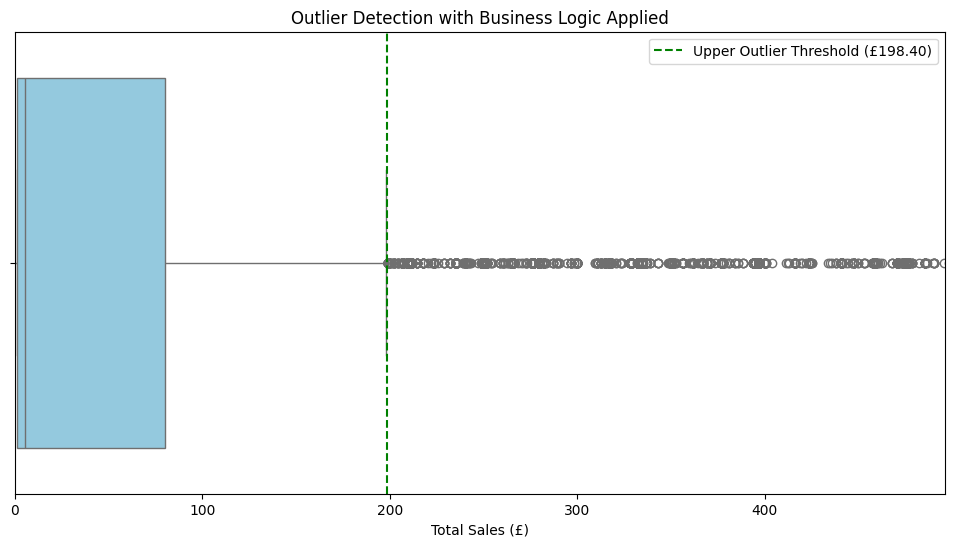

In [63]:
# 1. Standard Statistical Calculations
Q1 = df_sales["TotalPrice"].quantile(0.25)
Q3 = df_sales["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1

# 2. Mathematical Bounds
math_lower_bound = Q1 - 1.5 * IQR
math_upper_bound = Q3 + 1.5 * IQR

# 3. Logical Business Bounds (The "Retail Filter")
# We use max(0, ...) to ensure the line never goes below zero
effective_lower_bound = max(0, math_lower_bound)
effective_upper_bound = math_upper_bound

plt.figure(figsize=(12, 6))

# Plot the boxplot
sns.boxplot(x=df_sales["TotalPrice"], color="skyblue")

# Add the logical threshold line
plt.axvline(effective_upper_bound, color="green", linestyle="--", 
            label=f"Upper Outlier Threshold (£{effective_upper_bound:.2f})")

# Only plot lower bound if it's actually above 0 (rare in retail)
if math_lower_bound > 0:
    plt.axvline(effective_lower_bound, color="red", linestyle="--", label="Lower Outlier Threshold")

# Set the view to focus on the data, starting at 0
plt.xlim(0, effective_upper_bound * 2.5) 

plt.title("Outlier Detection with Business Logic Applied")
plt.xlabel("Total Sales (£)")
plt.legend()
plt.show()

#### Add Date features

In [64]:
# Create useful date features from the 'SaleDate' column
df_sales['Year'] = pd.to_datetime(df_sales['SalesDate']).dt.year
df_sales['Month'] = pd.to_datetime(df_sales['SalesDate']).dt.month
df_sales['MonthName'] = pd.to_datetime(df_sales['SalesDate']).dt.month_name()
df_sales['Day'] = pd.to_datetime(df_sales['SalesDate']).dt.day
df_sales['DayName'] = pd.to_datetime(df_sales['SalesDate']).dt.day_name()

ValueError: time data "20/04/2024 19:27" doesn't match format "%m/%d/%Y %H:%M", at position 8. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
df_sales.sample(5)

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Year,Month,MonthName,Day,DayName
38406,38407,9,15527,420,4,0.00,279.679993,2024-08-31 18:01:00,T-507766,2024,8,August,31,Saturday
18128,18129,14,76379,405,20,0.15,7.200000,2023-11-13 09:05:00,T-506181,2023,11,November,13,Monday
27514,27515,2,76379,405,17,0.15,6.120000,2024-07-11 14:13:00,T-501044,2024,7,July,11,Thursday
36692,36693,3,67309,405,3,0.00,1.290000,2023-06-05 15:18:00,T-512493,2023,6,June,5,Monday
5232,5233,18,76379,200,1,0.00,11.130000,2023-02-16 15:22:00,T-505852,2023,2,February,16,Thursday


#### Add Time features

In [ ]:
# Create time features from 'SalesDate' column
df_sales['Hour'] = pd.to_datetime(df_sales['SalesDate']).dt.hour
df_sales['Minute'] = pd.to_datetime(df_sales['SalesDate']).dt.minute

#### Add TimeOfDay

In [ ]:
# Define the bins (hours) and the labels for the time of day
bins = [0, 6, 11, 14, 18, 24]
labels = ['Late Night', 'Morning', 'Lunchtime', 'Afternoon', 'Evening']

# Categorize the hours 
df_sales['TimeOfDay'] = pd.cut(df_sales['Hour'], bins=bins, labels=labels, right=False)

In [ ]:
df_sales.head(5)

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Year,Month,MonthName,Day,DayName,Hour,Minute,TimeOfDay
0,1,23,85448,200,2,0.00,22.260000,2024-06-09 11:53:00,T-500771,2024,6,June,9,Sunday,11,53,Lunchtime
1,2,19,15527,405,3,0.00,1.290000,2023-12-12 10:31:00,T-503324,2023,12,December,12,Tuesday,10,31,Morning
2,3,19,5660,200,5,0.05,52.849998,2024-12-07 08:33:00,T-502966,2024,12,December,7,Saturday,8,33,Morning
3,4,13,87241,405,1,0.00,0.430000,2023-01-06 11:06:00,T-503874,2023,1,January,6,Friday,11,6,Lunchtime
4,5,21,76379,405,1,0.00,0.430000,2024-08-03 14:13:00,T-503393,2024,8,August,3,Saturday,14,13,Afternoon


#### Data Integrity Check - CustomerID

In [ ]:
# Perform a left join to see which sales have matching customers
check_df = pd.merge(df_sales, df_customers[['CustomerID']], on='CustomerID', how='left', indicator=True)

# Find the orphans (where the merge failed)
orphans = check_df[check_df['_merge'] == 'left_only']

print(f"Total Sales Records: {len(df_sales)}")
print(f"Orphaned Sales Records: {len(orphans)}")

Total Sales Records: 41140
Orphaned Sales Records: 0


#### Data Integrity Check - ProductID

In [ ]:
# Perform a left join to see which sales have matching products
check_df = pd.merge(df_sales, df_products[['ProductID']], on='ProductID', how='left', indicator=True)

# Find the orphans (where the merge failed)
orphans = check_df[check_df['_merge'] == 'left_only']

print(f"Total Sales Records: {len(df_sales)}")
print(f"Orphaned Sales Records: {len(orphans)}")

Total Sales Records: 41140
Orphaned Sales Records: 0


#### Data Integrity Check - TotalPrice

In [ ]:
# Map to get the UnitPrice from products table
price_map = df_products.set_index('ProductID')['Price']
df_sales['UnitPrice'] = df_sales['ProductID'].map(price_map).fillna(0).round(2)

# Calculate the price after discount
df_sales['ActualUnitPrice'] = df_sales['UnitPrice'] * (1 - df_sales['Discount']).round(2)

# Calculate the expected TotalPriceClean
df_sales['TotalPriceClean'] = (df_sales['ActualUnitPrice'] * df_sales['Quantity']).round(2)

# Rounded 2 decimal number to 'TotalPrice'
df_sales['TotalPrice'] = df_sales['TotalPrice'].round(2)

# Compare it against the recorded TotalPrice
df_sales['TotalPrice_Variance'] = df_sales['TotalPrice'] - df_sales['TotalPriceClean']

# Identify rows with errors 
price_errors = df_sales[abs(df_sales['TotalPrice_Variance']) > 1]
print(f"Data Quality Alert: Found {len(price_errors)} rows with price inconsistencies.")

Data Quality Alert: Found 0 rows with price inconsistencies.


In [ ]:
# Save the enriched DataFrame back to SQL Server
df_sales.to_sql('fact_sales', engine, if_exists='replace', index=False)

55

In [ ]:
df_sales165 = df_sales[df_sales['ProductID'] == 165]

In [ ]:
df_sales165.head()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Year,...,MonthName,Day,DayName,Hour,Minute,TimeOfDay,UnitPrice,ActualUnitPrice,TotalPriceClean,TotalPrice_Variance
39373,39374,23,76379,165,7,0.05,0.28,2023-05-06 14:53:00,T-510141,2023,...,May,6,Saturday,14,53,Afternoon,0.04,0.038,0.27,0.01
